In [1]:
import pandas as pd
import numpy as np



In [3]:
import numpy as np


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


In [7]:
# Warnings
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [9]:
file_path = "C:/Users/HomePC/Downloads/QVI_purchase_behaviour.csv"
file_paths = "C:/Users/HomePC/Downloads/QVI_transaction_data.xlsx"


In [11]:

Customer_data = pd.read_csv(file_path)


# df = pd.read_csv(file_path,"QVI_purchase_behaviour.csv")



In [13]:
Customer_data.head(10)


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [15]:
Transaction_data = pd.read_excel(file_paths)

In [17]:
Transaction_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [19]:
Transaction_data.tail(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8
264835,43365,272,272380,270189,74,Tostitos Splash Of Lime 175g,2,8.8


In [21]:
# Examine the transaction data
Transaction_data.shape


(264836, 8)

In [23]:
Transaction_data.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')

In [25]:
# to check datatype and the missing values ontransaction data

Transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [27]:
# DATE is an Excel serial number (example: 43533) and conert to datetime
Transaction_data["DATE"] = pd.to_datetime(Transaction_data["DATE"], origin="1899-12-30", unit="D")

In [29]:
Transaction_data["DATE"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [31]:
Transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [33]:
Transaction_data.duplicated().sum()

1

In [35]:
# time to examine our product name
Transaction_data["PROD_NAME"].describe(include="all")

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

In [37]:
# further examine on PROD_NAME
# Examine the words in PROD_NAME to see if there are any incorrect entries
# such as products that are not chips
Transaction_data["PROD_NAME"].head(10)

0      Natural Chip        Compny SeaSalt175g
1                    CCs Nacho Cheese    175g
2      Smiths Crinkle Cut  Chips Chicken 170g
3      Smiths Chip Thinly  S/Cream&Onion 175g
4    Kettle Tortilla ChpsHny&Jlpno Chili 150g
5    Old El Paso Salsa   Dip Tomato Mild 300g
6    Smiths Crinkle Chips Salt & Vinegar 330g
7       Grain Waves         Sweet Chilli 210g
8     Doritos Corn Chip Mexican Jalapeno 150g
9       Grain Waves Sour    Cream&Chives 210G
Name: PROD_NAME, dtype: object

In [39]:
# Explanation:
# dropna() removes missing value
# unique() gets unique product names
# " ".join(...) combines them into one long string
# split() breaks the string into individual words

productWords = pd.DataFrame({
    "word": " ".join(Transaction_data["PROD_NAME"].dropna().unique()).split()
})

In [41]:
# to renaming the column
productWords.columns = ['words']

In [43]:
# As we are only interested in words that will tell us if the product is chips or
# not, let's remove all words with digits and special characters such as '&' from our
# set of product words. 
import pandas as pd
import re

# assuming productWords is a DataFrame with column "words"
productWords["words"] = productWords["words"].astype(str)

# remove digits and special characters (keep only letters)
productWords["words"] = productWords["words"].str.replace(r"[^A-Za-z\s]", "", regex=True)

# remove empty strings
productWords = productWords[productWords["words"].str.strip() != ""]

# convert to lowercase (optional but recommended)
productWords["words"] = productWords["words"].str.lower()

# count frequency and sort
word_freq = productWords["words"].value_counts().reset_index()
word_freq.columns = ["word", "frequency"]

print(word_freq)



           word  frequency
0             g        107
1         chips         21
2        smiths         16
3       crinkle         14
4           cut         14
..          ...        ...
190  mozzarella          1
191       roast          1
192    chickeng          1
193         chp          1
194   bolognese          1

[195 rows x 2 columns]


In [45]:
#### Remove salsa products

# Create SALSA column (True if "salsa" is in PROD_NAME)
Transaction_data["SALSA"] = Transaction_data["PROD_NAME"].str.lower().str.contains("salsa", na=False)

# Remove rows where SALSA is True
Transaction_data = Transaction_data[Transaction_data["SALSA"] == False]

# Drop the SALSA column
Transaction_data = Transaction_data.drop(columns=["SALSA"])

In [47]:
# Next, we can use `summary()` to check summary statistics such as mean, min and max
 # values for each feature to see if there are any obvious outliers in the data and if
# there are any nulls in any of the columns (`NA's : number of nulls` will appear in
# the output if there are any nulls).

Transaction_data.describe(include='all')

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742,246742.000000,246742.000000
unique,NaN,NaN,NaN,NaN,NaN,105,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Kettle Mozzarella Basil & Pesto 175g,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,3304,NaN,NaN
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,NaN,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,NaN,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,NaN,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,NaN,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,NaN,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,NaN,200.000000,650.000000


In [49]:
Transaction_data["PROD_NAME"].head(10)

0       Natural Chip        Compny SeaSalt175g
1                     CCs Nacho Cheese    175g
2       Smiths Crinkle Cut  Chips Chicken 170g
3       Smiths Chip Thinly  S/Cream&Onion 175g
4     Kettle Tortilla ChpsHny&Jlpno Chili 150g
6     Smiths Crinkle Chips Salt & Vinegar 330g
7        Grain Waves         Sweet Chilli 210g
8      Doritos Corn Chip Mexican Jalapeno 150g
9        Grain Waves Sour    Cream&Chives 210G
10    Smiths Crinkle Chips Salt & Vinegar 330g
Name: PROD_NAME, dtype: object

In [51]:
#There are no nulls in the columns but product quantity appears to have an outlier
#which we should investigate further. Let's investigate further the case where 200
#packets of chips are bought in one transaction.

# Filter outliers using IQR
Q1 = Transaction_data["PROD_QTY"].quantile(0.25)
Q3 = Transaction_data["PROD_QTY"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = Transaction_data[
    (Transaction_data["PROD_QTY"] < lower_bound) |
    (Transaction_data["PROD_QTY"] > upper_bound)
]

print(outliers)

             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
1      2019-05-14          1            1307     348        66   
3      2018-08-17          2            2373     974        69   
4      2018-08-18          2            2426    1038       108   
6      2019-05-16          4            4149    3333        16   
7      2019-05-16          4            4196    3539        24   
...           ...        ...             ...     ...       ...   
264754 2018-10-07        268          268396  264841         8   
264755 2018-10-22        268          268463  264916        87   
264756 2019-04-28        268          268491  264947        56   
264824 2019-03-13        272          272193  269906         9   
264832 2018-08-13        272          272358  270154        74   

                                       PROD_NAME  PROD_QTY  TOT_SALES  
1                       CCs Nacho Cheese    175g         3        6.3  
3         Smiths Chip Thinly  S/Cream&Onion 175g         5     

In [53]:
#Show the bounds
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 2.0
Upper Bound: 2.0


In [55]:

#Count how many outliers
print("Number of outliers:", outliers.shape[0])

Number of outliers: 26672


In [57]:
# View transactions with high product quantity
Transaction_data[Transaction_data["PROD_QTY"] > 10]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [59]:

# Filter using the outlier bounds (IQR method)

outlier_transactions = Transaction_data[
    (Transaction_data["PROD_QTY"] < lower_bound) |
    (Transaction_data["PROD_QTY"] > upper_bound)
]

outlier_transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
...,...,...,...,...,...,...,...,...
264754,2018-10-07,268,268396,264841,8,Smiths Crinkle Cut Chips Original 170g,1,2.9
264755,2018-10-22,268,268463,264916,87,Infuzions BBQ Rib Prawn Crackers 110g,1,3.8
264756,2019-04-28,268,268491,264947,56,Cheezels Cheese Box 125g,1,2.1
264824,2019-03-13,272,272193,269906,9,Kettle Tortilla ChpsBtroot&Ricotta 150g,1,4.6


In [61]:
# View only selected columns (cleaner)
outlier_transactions[["DATE", "LYLTY_CARD_NBR", "PROD_NAME", "PROD_QTY", "TOT_SALES"]]

,DATE,LYLTY_CARD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
1,2019-05-14,1307,CCs Nacho Cheese 175g,3,6.3
3,2018-08-17,2373,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2426,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
6,2019-05-16,4149,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4196,Grain Waves Sweet Chilli 210g,1,3.6
...,...,...,...,...,...
264754,2018-10-07,268396,Smiths Crinkle Cut Chips Original 170g,1,2.9
264755,2018-10-22,268463,Infuzions BBQ Rib Prawn Crackers 110g,1,3.8
264756,2019-04-28,268491,Cheezels Cheese Box 125g,1,2.1
264824,2019-03-13,272193,Kettle Tortilla ChpsBtroot&Ricotta 150g,1,4.6


In [63]:
# Sort to see the largest quantity transactions
# This helps you examine the exact transactions causing the outliers.
outlier_transactions.sort_values(by="PROD_QTY", ascending=False)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
99556,2018-08-18,169,169213,171288,8,Smiths Crinkle Cut Chips Original 170g,5,14.5
171957,2019-05-14,96,96063,95846,15,Twisties Cheese 270g,5,23.0
151041,2019-05-20,230,230221,233463,38,Infuzions Mango Chutny Papadums 70g,5,12.0
...,...,...,...,...,...,...,...,...
100845,2019-06-16,16,16501,14610,80,Natural ChipCo Sea Salt & Vinegr 175g,1,3.0
100844,2019-01-03,16,16501,14609,34,Pringles Slt Vingar 134g,1,3.7
100843,2018-10-10,16,16501,14608,48,Red Rock Deli Sp Salt & Truffle 150G,1,2.7
100842,2018-11-02,16,16467,14582,32,Kettle Sea Salt And Vinegar 175g,1,5.4


In [65]:
# o check if that customer made other transactions, first get the customer ID 
# (e.g. LYLTY_CARD_NBR) from the outlier row, then filter the dataset.
# Filter all transactions for a specific customer

customer_id = outlier_transactions["LYLTY_CARD_NBR"].iloc[0]

customer_transactions = Transaction_data[
    Transaction_data["LYLTY_CARD_NBR"] == customer_id
]

customer_transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
209,2018-11-10,1,1307,346,96,WW Original Stacked Chips 160g,2,3.8
210,2019-03-09,1,1307,347,54,CCs Original 175g,1,2.1


In [67]:
# Sort by date (to view properly)
customer_transactions = customer_transactions.sort_values(by="DATE")
customer_transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
209,2018-11-10,1,1307,346,96,WW Original Stacked Chips 160g,2,3.8
210,2019-03-09,1,1307,347,54,CCs Original 175g,1,2.1
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3


In [69]:
# Show only important columns
# This will display all transactions made by that customer so you can see 
# if the outlier was a one-time event or a repeated pattern.

customer_transactions[["DATE", "PROD_NAME", "PROD_QTY", "TOT_SALES"]]

,DATE,PROD_NAME,PROD_QTY,TOT_SALES
209,2018-11-10,WW Original Stacked Chips 160g,2,3.8
210,2019-03-09,CCs Original 175g,1,2.1
1,2019-05-14,CCs Nacho Cheese 175g,3,6.3


In [71]:
# Filter out the customer based on the loyalty card number
# Remove that customer’s transactions
loyalty_number = 226000  # replace with the loyalty card number

Transaction_data = Transaction_data[Transaction_data["LYLTY_CARD_NBR"] != loyalty_number]

In [73]:
# If you want to store the filtered dataset separately

filteredData = Transaction_data[Transaction_data["LYLTY_CARD_NBR"] != loyalty_number]

In [75]:
# Re-examine transaction data
# onfirm the customer is removed

Transaction_data[Transaction_data["LYLTY_CARD_NBR"] == loyalty_number]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


In [77]:
# let's look at the number of transaction lines over time to see
# if there are any obvious data issues such as missing data.
transactions_by_date = Transaction_data.groupby("DATE").size().reset_index(name="transaction_count")
print(transactions_by_date)

          DATE  transaction_count
0   2018-07-01                663
1   2018-07-02                650
2   2018-07-03                674
3   2018-07-04                669
4   2018-07-05                660
..         ...                ...
359 2019-06-26                657
360 2019-06-27                669
361 2019-06-28                673
362 2019-06-29                703
363 2019-06-30                704

[364 rows x 2 columns]


In [79]:
# Sort by date
transactions_by_date = transactions_by_date.sort_values("DATE")
print(transactions_by_date)

          DATE  transaction_count
0   2018-07-01                663
1   2018-07-02                650
2   2018-07-03                674
3   2018-07-04                669
4   2018-07-05                660
..         ...                ...
359 2019-06-26                657
360 2019-06-27                669
361 2019-06-28                673
362 2019-06-29                703
363 2019-06-30                704

[364 rows x 2 columns]


In [81]:
# f you want only the top busiest dates
Transaction_data["DATE"].value_counts().head(10)

DATE
2018-12-24    865
2018-12-23    853
2018-12-22    840
2018-12-19    839
2018-12-20    808
2018-12-18    799
2018-12-21    781
2019-06-07    762
2018-09-06    745
2019-06-14    743
Name: count, dtype: int64

In [136]:
# To create a summary of transaction count by date
transactions_summary = (
    Transaction_data.groupby("DATE")
    .size()
    .reset_index(name="Transaction_Count")
    .sort_values("DATE")
)

print(transactions_summary)

          DATE  Transaction_Count
0   2018-07-01                663
1   2018-07-02                650
2   2018-07-03                674
3   2018-07-04                669
4   2018-07-05                660
..         ...                ...
359 2019-06-26                657
360 2019-06-27                669
361 2019-06-28                673
362 2019-06-29                703
363 2019-06-30                704

[364 rows x 2 columns]


In [138]:
#There's only 364 rows, meaning only 364 dates which indicates a missing date. Let's
#create a sequence of dates from 1 Jul 2018 to 30 Jun 2019 and use this to create a
#chart of number of transactions over time to find the missing date

#create a column of dates that includes every day from 1 Jul 2018 to
#30 Jun 2019, and join it onto the data to fill in the missing day.

In [140]:


# make sure DATE is datetime
Transaction_data["DATE"] = pd.to_datetime(Transaction_data["DATE"])

# create full date range
all_dates = pd.DataFrame({
    "DATE": pd.date_range(start="2018-07-01", end="2019-06-30", freq="D")
})

# summary of transactions per day
daily_summary = Transaction_data.groupby("DATE").size().reset_index(name="Transaction_Count")

# join to include missing dates
daily_summary_full = all_dates.merge(daily_summary, on="DATE", how="left")

# fill missing days with 0 transactions
daily_summary_full["Transaction_Count"] = daily_summary_full["Transaction_Count"].fillna(0).astype(int)

print(daily_summary_full)

          DATE  Transaction_Count
0   2018-07-01                663
1   2018-07-02                650
2   2018-07-03                674
3   2018-07-04                669
4   2018-07-05                660
..         ...                ...
360 2019-06-26                657
361 2019-06-27                669
362 2019-06-28                673
363 2019-06-29                703
364 2019-06-30                704

[365 rows x 2 columns]


In [142]:
# Setting plot themes to format graphs
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")   # similar to theme_bw()

In [150]:
transactions_by_day = (
    Transaction_data.groupby("DATE")
    .size()
    .reset_index(name="N")
    .sort_values("DATE")
)

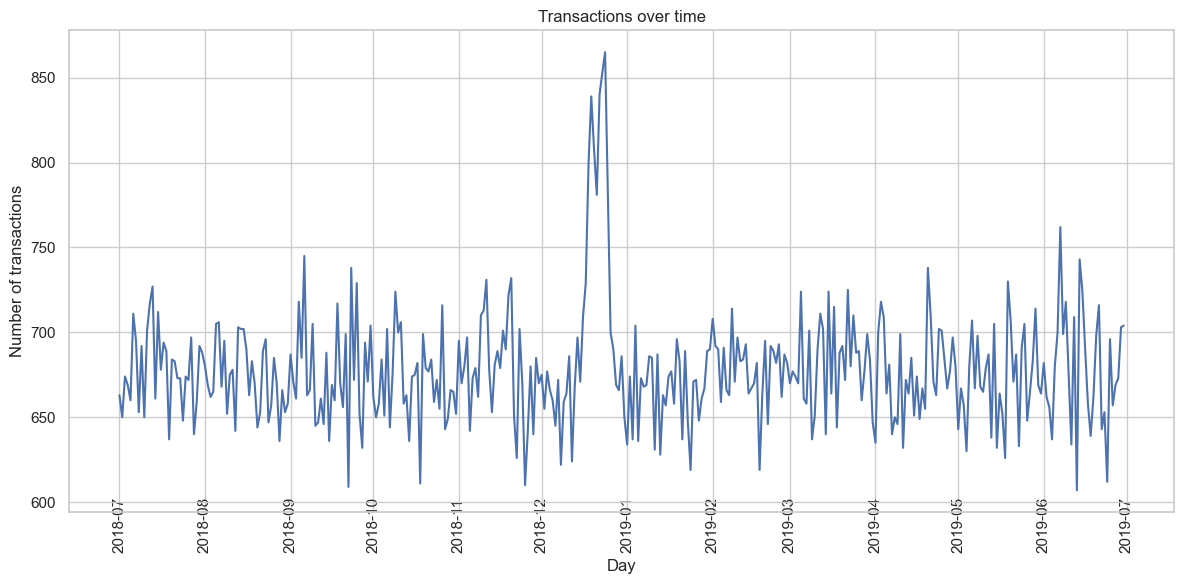

In [146]:
# Plot transactions over time

# style similar to ggplot theme
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

# line plot
plt.plot(transactions_by_day["DATE"], transactions_by_day["N"])
# labels and title
plt.xlabel("Day")
plt.ylabel("Number of transactions")
plt.title("Transactions over time")

# show x-axis breaks every 1 month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# rotate x-axis labels
plt.xticks(rotation=90, va="center")

plt.tight_layout()
plt.show()


In [95]:
#To filter your transaction summary to December and view individual days:
december_data = transactions_by_date[transactions_by_date["DATE"].dt.month == 12]
print(december_data)

          DATE  transaction_count
153 2018-12-01                675
154 2018-12-02                655
155 2018-12-03                677
156 2018-12-04                666
157 2018-12-05                660
158 2018-12-06                645
159 2018-12-07                672
160 2018-12-08                622
161 2018-12-09                659
162 2018-12-10                664
163 2018-12-11                686
164 2018-12-12                624
165 2018-12-13                668
166 2018-12-14                697
167 2018-12-15                671
168 2018-12-16                709
169 2018-12-17                729
170 2018-12-18                799
171 2018-12-19                839
172 2018-12-20                808
173 2018-12-21                781
174 2018-12-22                840
175 2018-12-23                853
176 2018-12-24                865
177 2018-12-26                700
178 2018-12-27                690
179 2018-12-28                669
180 2018-12-29                666
181 2018-12-30

In [97]:
# Sort by day (if not already sorted)
december_data = december_data.sort_values("DATE")
print(december_data)

          DATE  transaction_count
153 2018-12-01                675
154 2018-12-02                655
155 2018-12-03                677
156 2018-12-04                666
157 2018-12-05                660
158 2018-12-06                645
159 2018-12-07                672
160 2018-12-08                622
161 2018-12-09                659
162 2018-12-10                664
163 2018-12-11                686
164 2018-12-12                624
165 2018-12-13                668
166 2018-12-14                697
167 2018-12-15                671
168 2018-12-16                709
169 2018-12-17                729
170 2018-12-18                799
171 2018-12-19                839
172 2018-12-20                808
173 2018-12-21                781
174 2018-12-22                840
175 2018-12-23                853
176 2018-12-24                865
177 2018-12-26                700
178 2018-12-27                690
179 2018-12-28                669
180 2018-12-29                666
181 2018-12-30

In [238]:
# make sure DATE is datetime
transactions_by_date["DATE"] = pd.to_datetime(transactions_by_date["DATE"])

# filter to December (example: Dec 2018)
december_data = transactions_by_date[
    (transactions_by_date["DATE"].dt.year == 2018) &
    (transactions_by_date["DATE"].dt.month == 12)
]

In [103]:
#We can see that the increase in sales occurs in the lead-up to Christmas and that
#there are zero sales on Christmas day itself. This is due to shops being closed on
#Christmas day.

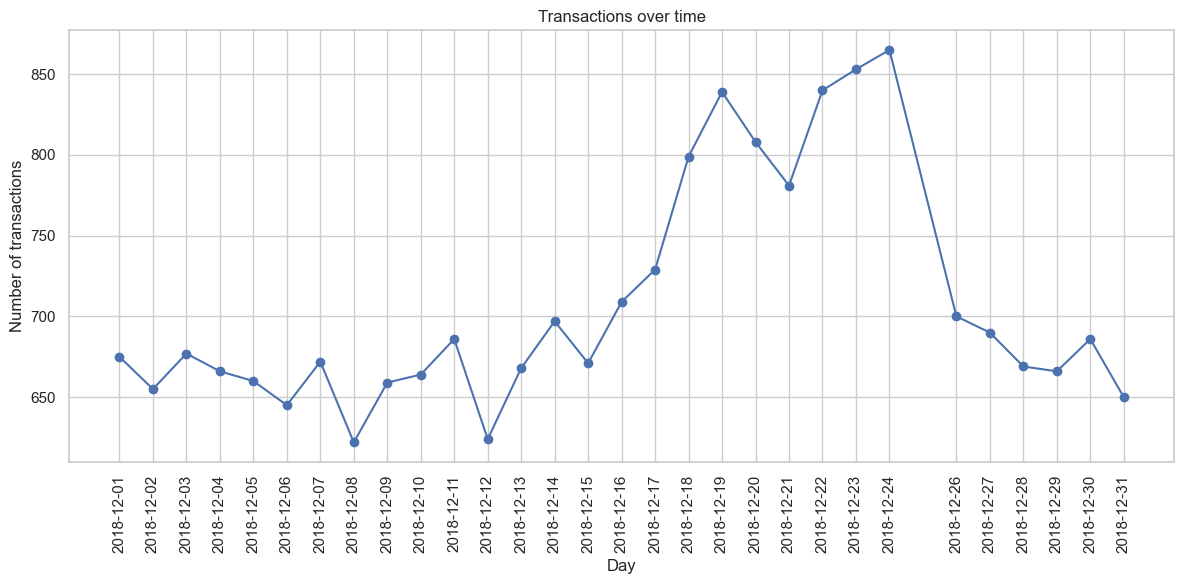

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure DATE is datetime
transactions_by_day["DATE"] = pd.to_datetime(transactions_by_day["DATE"])

# Filter to only December
december_data = transactions_by_day[transactions_by_day["DATE"].dt.month == 12]

# Plot
plt.figure(figsize=(12,6))
plt.plot(december_data["DATE"], december_data["N"], marker="o")

plt.xlabel("Day")
plt.ylabel("Number of transactions")
plt.title("Transactions over time")

# Show every day as x-axis tick
plt.xticks(december_data["DATE"], rotation=90)

plt.tight_layout()
plt.show()

We can see that the increase in sales occurs in the lead-up to Christmas and that there are zero sales on
Christmas day itself. This is due to shops being closed on Christmas day.
Now that we are satisfied that the data no longer has outliers, we can move on to creating other features
such as brand of chips or pack size from PROD_NAME. We will start with pack size.

In [166]:
# let create pack size
# Le can work this out by taking the digits that are in PROD_NAME

Transaction_data["PACK_SIZE"] = pd.to_numeric(
    Transaction_data["PROD_NAME"].str.extract(r'(\d+)')[0],
    errors="coerce"
)

In [168]:
pack_size_count = (
    Transaction_data.groupby("PACK_SIZE")
    .size()
    .reset_index(name="N")
    .sort_values("PACK_SIZE")
)

print(pack_size_count)

    PACK_SIZE      N
0          70   1507
1          90   3008
2         110  22387
3         125   1454
4         134  25102
5         135   3257
6         150  40203
7         160   2970
8         165  15297
9         170  19983
10        175  66390
11        180   1468
12        190   2995
13        200   4473
14        210   6272
15        220   1564
16        250   3169
17        270   6285
18        330  12540
19        380   6416


#The largest size is 380g and the smallest size is 70g - seems sensible!
Let's plot a histogram of PACK_SIZE since we know that it is a categorical
variable and not a continuous variable even though it is numeric.

In [173]:
# Let's check the output of the first few rows to see if we have indeed
 # picked out pack size.
Transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCS
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,SMITHS
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,SMITHS
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,KETTLE
...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,KETTLE
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,TOSTITOS
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,DORITOS
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,DORITOS


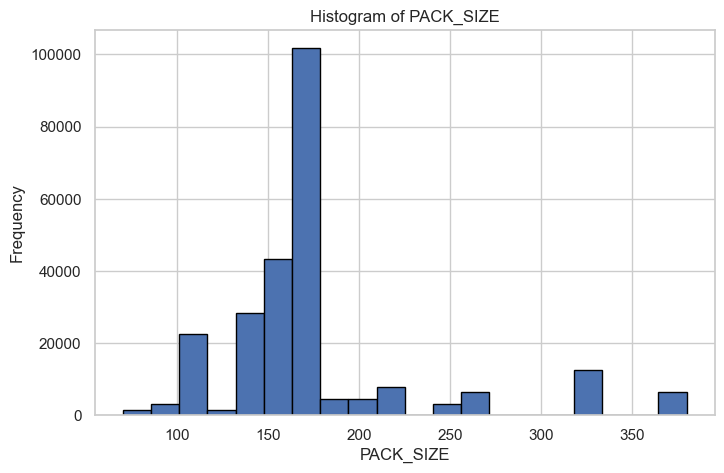

In [175]:


plt.figure(figsize=(8,5))
plt.hist(Transaction_data["PACK_SIZE"], bins=20, edgecolor="black")

plt.xlabel("PACK_SIZE")
plt.ylabel("Frequency")
plt.title("Histogram of PACK_SIZE")

plt.show()

Pack sizes created look reasonable and now to create brands, we can use the first word in PROD_NAME to
work out the brand name

In [180]:
print(Transaction_data["BRAND"].value_counts())

BRAND
KETTLE        41288
SMITHS        30353
DORITOS       25224
PRINGLES      25102
RRD           16321
INFUZIONS     14201
THINS         14075
WOOLWORTHS    11836
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
CHEEZELS       4603
CCS            4551
CHEETOS        2927
SNBTS          1576
BURGER         1564
GRNWV          1468
SUNBITES       1432
NCC            1419
FRENCH         1418
Name: count, dtype: int64


In [112]:
# Now to create brands, we can use the first word in PROD_NAME to work out the brand
# name
#Create a column which contains the brand of the product, by
#extracting it from the product name
import pandas as pd

# extract the first word as brand
Transaction_data["BRAND"] = Transaction_data["PROD_NAME"].str.split().str[0]

# view the result
Transaction_data[["PROD_NAME", "BRAND"]].head()


,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle


In [114]:
Transaction_data[["PROD_NAME", "BRAND"]].head(10)

,PROD_NAME,BRAND
0,Natural Chip Compny SeaSalt175g,Natural
1,CCs Nacho Cheese 175g,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle
6,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths
7,Grain Waves Sweet Chilli 210g,Grain
8,Doritos Corn Chip Mexican Jalapeno 150g,Doritos
9,Grain Waves Sour Cream&Chives 210G,Grain
10,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths


Some of the brand names look like they are of the same brands - such as RED and RRD, which are both Red
Rock Deli chips. Let’s combine these together

In [185]:
Transaction_data.loc[Transaction_data["BRAND"] == "RED", "BRAND"] = "RRD"
Transaction_data.loc[Transaction_data["BRAND"] == "SNBTS", "BRAND"] = "SUNBITES"
Transaction_data.loc[Transaction_data["BRAND"] == "INFZNS", "BRAND"] = "INFUZIONS"
Transaction_data.loc[Transaction_data["BRAND"] == "WW", "BRAND"] = "WOOLWORTHS"
Transaction_data.loc[Transaction_data["BRAND"] == "SMITH", "BRAND"] = "SMITHS"
Transaction_data.loc[Transaction_data["BRAND"] == "NCC", "BRAND"] = "NATURAL"
Transaction_data.loc[Transaction_data["BRAND"] == "DORITO", "BRAND"] = "DORITOS"
Transaction_data.loc[Transaction_data["BRAND"] == "GRAIN", "BRAND"] = "GRNWVES"

In [187]:
print(Transaction_data["BRAND"].value_counts().sort_index())

BRAND
BURGER         1564
CCS            4551
CHEETOS        2927
CHEEZELS       4603
COBS           9693
DORITOS       25224
FRENCH         1418
GRNWV          1468
GRNWVES        6272
INFUZIONS     14201
KETTLE        41288
NATURAL        7469
PRINGLES      25102
RRD           16321
SMITHS        30353
SUNBITES       3008
THINS         14075
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
WOOLWORTHS    11836
Name: count, dtype: int64


In [116]:
# Clean brand names
Transaction_data.loc[Transaction_data["BRAND"] == "RED", "BRAND"] = "RRD"

In [118]:
Transaction_data["BRAND"].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

In [120]:
# Check the results in several ways to see if the BRAND column looks correct:

brand_counts = Transaction_data["BRAND"].value_counts()
print(brand_counts)

BRAND
Kettle        41288
Smiths        27390
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64


In [122]:
# Count transactions per brand

Transaction_data["BRAND"].value_counts().head(10)

BRAND
Kettle       41288
Smiths       27390
Pringles     25102
Doritos      22041
Thins        14075
RRD          11894
Infuzions    11057
WW           10320
Cobs          9693
Tostitos      9471
Name: count, dtype: int64

In [124]:
# Perfect! You can create a summary table of 
# brands, pack sizes, and number of transactions like this:

# Group by BRAND and PACK_SIZE, count transactions
brand_pack_summary = (
    Transaction_data.groupby(["BRAND", "PACK_SIZE"])
    .size()  # counts the number of transactions
    .reset_index(name="Transaction_Count")
    .sort_values(["BRAND", "PACK_SIZE"])
)

# View the first few rows
print(brand_pack_summary.head(20))


#What this does:
#groupby(["BRAND", "PACK_SIZE"]) → groups data by brand and pack size.
#.size() → counts the number of transactions in each group.
#.reset_index(name="Transaction_Count") → turns it into a nice table.
#.sort_values(["BRAND", "PACK_SIZE"]) → sorts first by brand, then pack size.

        BRAND  PACK_SIZE  Transaction_Count
0      Burger        220               1564
1         CCs        175               4551
2     Cheetos        165               1448
3     Cheetos        190               1479
4    Cheezels        125               1454
5    Cheezels        330               3149
6        Cobs        110               9693
7      Dorito        380               3183
8     Doritos        150               6376
9     Doritos        170              12613
10    Doritos        330               3052
11     French        175               1418
12      Grain        210               6272
13    GrnWves        180               1468
14  Infuzions         70               1507
15  Infuzions        110               9550
16     Infzns        110               3144
17     Kettle        135               3257
18     Kettle        150              19009
19     Kettle        175              19022


In [126]:
# To adjust common brand issues
# convert to uppercase first for consistency
Transaction_data["BRAND"] = Transaction_data["BRAND"].str.upper()

# brand corrections (dictionary mapping)
brand_corrections = {
    "RED": "RRD",
    "RRD": "RRD",
    "INFZNS": "INFUZIONS",
    "INFUZION": "INFUZIONS",
    "SMITH": "SMITHS",
    "DORITO": "DORITOS",
    "NATURAL": "NATURAL",
    "GRNWVES": "GRNWV",
    "SUNBITE": "SUNBITES",
    "WW": "WOOLWORTHS",
    "WOOLWORTH": "WOOLWORTHS"
}

# apply corrections
Transaction_data["BRAND"] = Transaction_data["BRAND"].replace(brand_corrections)

# check top brands again
print(Transaction_data["BRAND"].value_counts().head(20))


BRAND
KETTLE        41288
SMITHS        30353
DORITOS       25224
PRINGLES      25102
RRD           16321
INFUZIONS     14201
THINS         14075
WOOLWORTHS    11836
COBS           9693
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
GRAIN          6272
NATURAL        6050
CHEEZELS       4603
CCS            4551
CHEETOS        2927
SNBTS          1576
BURGER         1564
GRNWV          1468
Name: count, dtype: int64


In [130]:
# Examining customer data
#Now that we are happy with the transaction dataset, let's have a look at the
#customer dataset.

In [189]:
# Exploratory data analysis
#Check first rows
Customer_data.head()


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [193]:
Customer_data.describe(include="all")

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
count,7.263700e+04,72637,72637
unique,NaN,7,3
top,NaN,RETIREES,Mainstream
freq,NaN,14805,29245
mean,1.361859e+05,NaN,NaN
std,8.989293e+04,NaN,NaN
min,1.000000e+03,NaN,NaN
25%,6.620200e+04,NaN,NaN
50%,1.340400e+05,NaN,NaN
75%,2.033750e+05,NaN,NaN


In [134]:
#Check dataset info (data types + missing values)
Customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


Let’s have a closer look at the LIFESTAGE and PREMIUM_CUSTOMER columns.

In [198]:
print(Customer_data["PREMIUM_CUSTOMER"].value_counts())

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [200]:
print(Customer_data["LIFESTAGE"].value_counts())

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64


As there do not seem to be any issues with the customer data, we can now go ahead and join the transaction
and customer data sets together

In [136]:
# checking missing values
Customer_data.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [ ]:
# Merge Transaction_data to Customer_data
data = Transaction_data.merge(Customer_data, how="left")

In [203]:
# Number of unique customers
Customer_data["LYLTY_CARD_NBR"].nunique()

72637

In [205]:
# Count customers by LIFESTAGE
Customer_data["LIFESTAGE"].value_counts()

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [207]:
# Count customers by PREMIUM CUSTOMER
Customer_data["PREMIUM_CUSTOMER"].value_counts()

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [209]:
# Cross-tab (LIFESTAGE vs PREMIUM CUSTOMER)
pd.crosstab(Customer_data["LIFESTAGE"], Customer_data["PREMIUM_CUSTOMER"])

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,1504,3340,2431
NEW FAMILIES,1112,849,588
OLDER FAMILIES,4675,2831,2274
OLDER SINGLES/COUPLES,4929,4930,4750
RETIREES,4454,6479,3872
YOUNG FAMILIES,4017,2728,2433
YOUNG SINGLES/COUPLES,3779,8088,2574


In [211]:
# Check duplicates (very important)
Customer_data.duplicated(subset="LYLTY_CARD_NBR").sum()

0

In [213]:
# Distribution (counts + percentages)
# LIFESTAGE distribution
Customer_data["LIFESTAGE"].value_counts()
Customer_data["LIFESTAGE"].value_counts(normalize=True) * 100

LIFESTAGE
RETIREES                  20.382174
OLDER SINGLES/COUPLES     20.112339
YOUNG SINGLES/COUPLES     19.881052
OLDER FAMILIES            13.464212
YOUNG FAMILIES            12.635434
MIDAGE SINGLES/COUPLES    10.015557
NEW FAMILIES               3.509231
Name: proportion, dtype: float64

In [150]:
# PREMIUM CUSTOMER distribution
Customer_data["PREMIUM_CUSTOMER"].value_counts()
Customer_data["PREMIUM_CUSTOMER"].value_counts(normalize=True) * 100

PREMIUM_CUSTOMER
Mainstream    40.261850
Budget        33.688065
Premium       26.050085
Name: proportion, dtype: float64

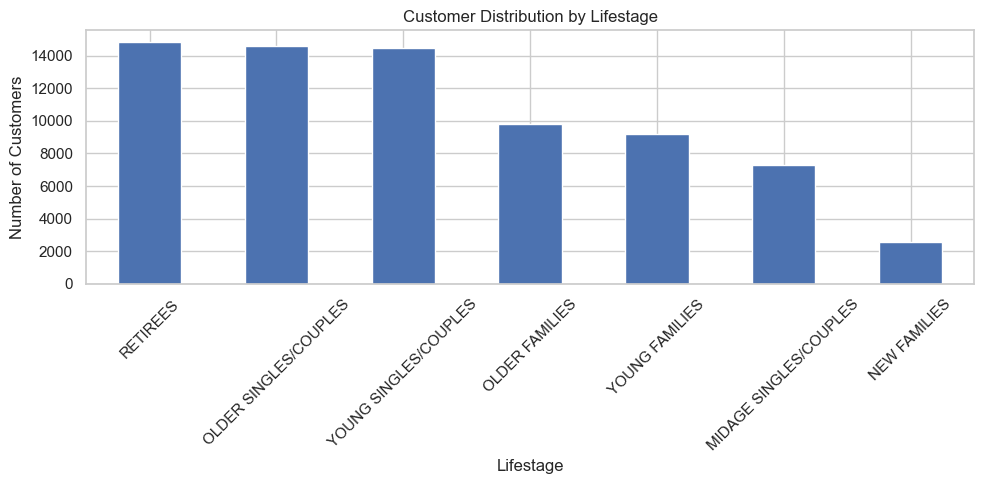

In [215]:
# Bar chart distribution (recommended)
# LIFESTAGE bar chart
#mport matplotlib.pyplot as plt

Customer_data["LIFESTAGE"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Customer Distribution by Lifestage")
plt.xlabel("Lifestage")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

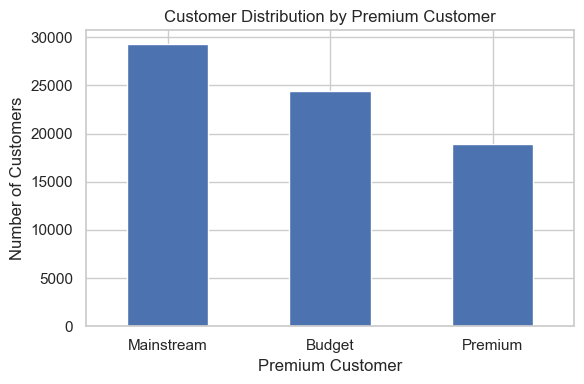

In [154]:
# PREMIUM CUSTOMER bar chart
Customer_data["PREMIUM_CUSTOMER"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Customer Distribution by Premium Customer")
plt.xlabel("Premium Customer")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [156]:
# Combined distribution (LIFESTAGE vs PREMIUM CUSTOMER)
cross_tab = pd.crosstab(Customer_data["LIFESTAGE"], Customer_data["PREMIUM_CUSTOMER"])
print(cross_tab)

PREMIUM_CUSTOMER        Budget  Mainstream  Premium
LIFESTAGE                                          
MIDAGE SINGLES/COUPLES    1504        3340     2431
NEW FAMILIES              1112         849      588
OLDER FAMILIES            4675        2831     2274
OLDER SINGLES/COUPLES     4929        4930     4750
RETIREES                  4454        6479     3872
YOUNG FAMILIES            4017        2728     2433
YOUNG SINGLES/COUPLES     3779        8088     2574


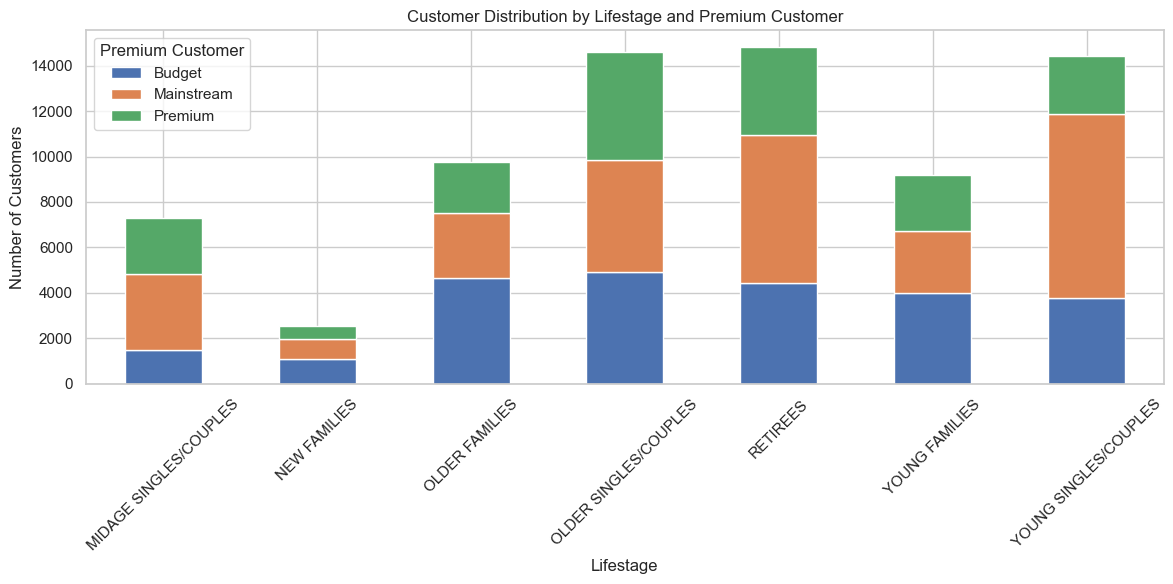

In [158]:
# stacked bar chart for LIFESTAGE vs PREMIUM CUSTOMER
#import pandas as pd
#import matplotlib.pyplot as plt

# create cross-tab table
cross_tab = pd.crosstab(Customer_data["LIFESTAGE"], Customer_data["PREMIUM_CUSTOMER"])

# plot stacked bar chart
cross_tab.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Customer Distribution by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Premium Customer")

plt.tight_layout()
plt.show()

In [217]:
# Merge transaction data to customer data
# is a left join
# This keeps all rows from transactionData and brings matching customer info from customerData.
data = Transaction_data.merge(Customer_data, on="LYLTY_CARD_NBR", how="left")

In [219]:
data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,KETTLE,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
246735,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,KETTLE,YOUNG SINGLES/COUPLES,Premium
246736,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,TOSTITOS,YOUNG SINGLES/COUPLES,Premium
246737,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,DORITOS,YOUNG SINGLES/COUPLES,Premium
246738,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,DORITOS,YOUNG SINGLES/COUPLES,Premium


In [221]:
missing_count = data["LIFESTAGE"].isna().sum()
print(missing_count)

0


In [223]:
missing_count = data["PREMIUM_CUSTOMER"].isna().sum()
print(missing_count)

0


Data analysis on customer segments
Now that the data is ready for analysis, we can define some metrics of interest to the client:
• Who spends the most on chips (total sales), describing customers by lifestage and how premium their
general purchasing behaviour is
• How many customers are in each segment
• How many chips are bought per customer by segment
• What’s the average chip price by customer segment
We could also ask our data team for more information. Examples are:

In [ ]:
The customer’s total spend over the period and total spend for each transaction to understand what
proportion of their grocery spend is on chips
• Proportion of customers in each customer segment overall to compare against the mix of customers
who purchase chips
Let’s start with calculating total sales by LIFESTAGE and PREMIUM_CUSTOMER and plotting the split by
these segments to describe which customer segment contribute most to chip sales.
#### Total sales by LIFESTAGE and PREMIUM_CUSTOMER

In [226]:
#Aggregate sales

sales = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .reset_index(name="SALES")
)

In [228]:
#Create mosaic plot (closest equivalent to geom_mosaic)
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt

In [230]:
#Convert data into mosaic format
mosaic_data = {
    (row["LIFESTAGE"], row["PREMIUM_CUSTOMER"]): row["SALES"]
    for _, row in sales.iterrows()
}

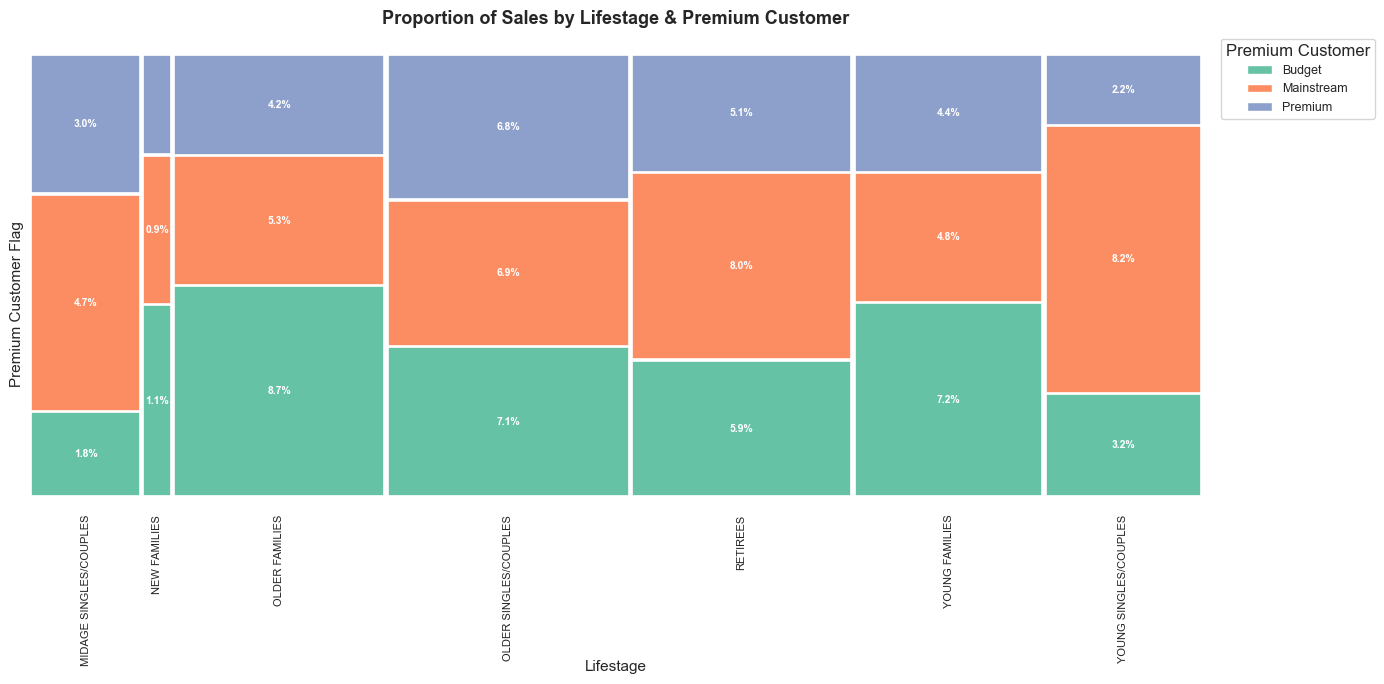

In [234]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Aggregate sales ──────────────────────────────────────────────────────
sales = (
    data
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'], as_index=False)['TOT_SALES']
    .sum()
    .rename(columns={'TOT_SALES': 'SALES'})
)

# ── 2. Pivot for mosaic layout ───────────────────────────────────────────────
pivot = sales.pivot(index='PREMIUM_CUSTOMER', columns='LIFESTAGE', values='SALES').fillna(0)

total = pivot.values.sum()
col_totals = pivot.sum(axis=0)   # width  of each LIFESTAGE column
row_totals = pivot.sum(axis=1)   # height of each PREMIUM_CUSTOMER row

# ── 3. Colours – one per PREMIUM_CUSTOMER tier ──────────────────────────────
tiers   = pivot.index.tolist()
palette = plt.cm.Set2.colors
colours = {tier: palette[i] for i, tier in enumerate(tiers)}

# ── 4. Draw mosaic tiles ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

x_cursor = 0.0
gap = 0.003   # thin gap between columns

for lifestage in pivot.columns:
    col_width = col_totals[lifestage] / total
    y_cursor  = 0.0

    for tier in tiers:
        cell_sales  = pivot.loc[tier, lifestage]
        cell_height = cell_sales / col_totals[lifestage] if col_totals[lifestage] > 0 else 0
        pct         = round(cell_sales / total * 100, 1)

        # Draw rectangle
        rect = mpatches.FancyBboxPatch(
            (x_cursor + gap / 2, y_cursor + gap / 2),
            col_width - gap,
            cell_height - gap,
            boxstyle="square,pad=0",
            facecolor=colours[tier],
            edgecolor='white',
            linewidth=1.2,
        )
        ax.add_patch(rect)

        # Label (only if tile is large enough to read)
        if pct >= 0.8:
            ax.text(
                x_cursor + col_width / 2,
                y_cursor + cell_height / 2,
                f"{pct}%",
                ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white'
            )

        y_cursor += cell_height

    # LIFESTAGE label below each column
    ax.text(
        x_cursor + col_width / 2, -0.04,
        lifestage,
        ha='center', va='top',
        fontsize=8, rotation=90
    )

    x_cursor += col_width

# ── 5. Legend ────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=colours[t], label=t) for t in tiers
]
ax.legend(
    handles=legend_patches,
    title='Premium Customer',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9
)

# ── 6. Formatting ─────────────────────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(-0.18, 1.05)
ax.set_title('Proportion of Sales by Lifestage & Premium Customer', fontsize=13, fontweight='bold')
ax.set_xlabel('Lifestage', fontsize=11, labelpad=60)
ax.set_ylabel('Premium Customer Flag', fontsize=11)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['top','right','bottom','left']].set_visible(False)

plt.tight_layout()
plt.show()

Sales are coming mainly from Budget - older families, Mainstream - young singles/couples, and Mainstream
- retirees
Let’s see if the higher sales are due to there being more customers who buy chips.

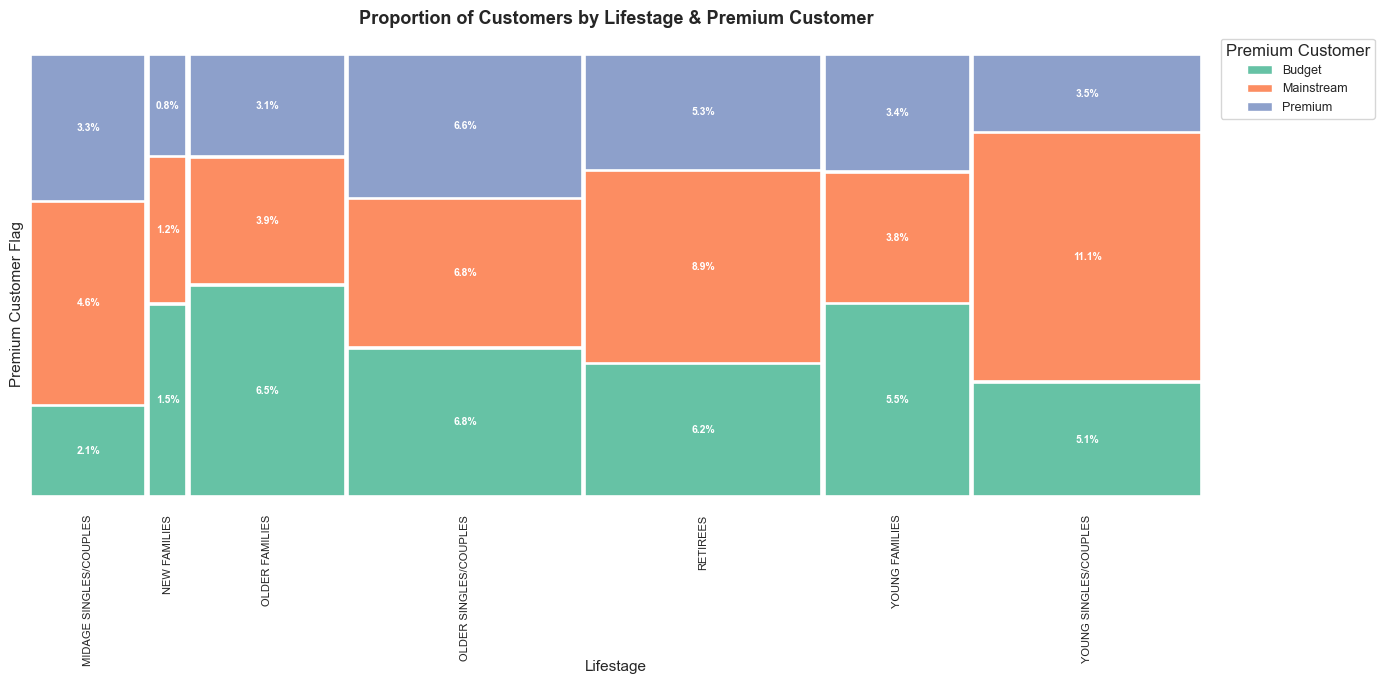

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Aggregate unique customers ────────────────────────────────────────────
customers = (
    data
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
    .nunique()
    .reset_index()
    .rename(columns={'LYLTY_CARD_NBR': 'CUSTOMERS'})
    .sort_values('CUSTOMERS', ascending=False)
)

# ── 2. Pivot for mosaic layout ───────────────────────────────────────────────
pivot = customers.pivot(
    index='PREMIUM_CUSTOMER',
    columns='LIFESTAGE',
    values='CUSTOMERS'
).fillna(0)

total      = pivot.values.sum()
col_totals = pivot.sum(axis=0)   # total customers per LIFESTAGE  → column width
row_totals = pivot.sum(axis=1)   # total customers per tier       → row height

# ── 3. Colours – one per PREMIUM_CUSTOMER tier ───────────────────────────────
tiers   = pivot.index.tolist()
palette = plt.cm.Set2.colors
colours = {tier: palette[i] for i, tier in enumerate(tiers)}

# ── 4. Draw mosaic tiles ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

x_cursor = 0.0
gap      = 0.003

for lifestage in pivot.columns:
    col_width = col_totals[lifestage] / total
    y_cursor  = 0.0

    for tier in tiers:
        cell_customers = pivot.loc[tier, lifestage]
        cell_height    = (
            cell_customers / col_totals[lifestage]
            if col_totals[lifestage] > 0 else 0
        )
        pct = round(cell_customers / total * 100, 1)

        # Draw rectangle
        rect = mpatches.FancyBboxPatch(
            (x_cursor + gap / 2, y_cursor + gap / 2),
            col_width - gap,
            cell_height - gap,
            boxstyle="square,pad=0",
            facecolor=colours[tier],
            edgecolor='white',
            linewidth=1.2,
        )
        ax.add_patch(rect)

        # Percentage label (only if tile is large enough)
        if pct >= 0.8:
            ax.text(
                x_cursor + col_width / 2,
                y_cursor + cell_height / 2,
                f"{pct}%",
                ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white'
            )

        y_cursor += cell_height

    # LIFESTAGE label below each column
    ax.text(
        x_cursor + col_width / 2, -0.04,
        lifestage,
        ha='center', va='top',
        fontsize=8, rotation=90
    )

    x_cursor += col_width

# ── 5. Legend ─────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=colours[t], label=t) for t in tiers
]
ax.legend(
    handles=legend_patches,
    title='Premium Customer',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9
)

# ── 6. Formatting ─────────────────────────────────────────────────────────────
ax.set_xlim(0, 1)
ax.set_ylim(-0.18, 1.05)
ax.set_title('Proportion of Customers by Lifestage & Premium Customer',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Lifestage', fontsize=11, labelpad=60)
ax.set_ylabel('Premium Customer Flag', fontsize=11)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

plt.tight_layout()
plt.show()

There are more Mainstream - young singles/couples and Mainstream - retirees who buy chips. This contributes
to there being more sales to these customer segments but this is not a major driver for the Budget
- Older families segment.
Higher sales may also be driven by more units of chips being bought per customer. Let’s have a look at this
next.

In [ ]:
#### Average number of units per customer by LIFESTAGE and PREMIUM_CUSTOMER

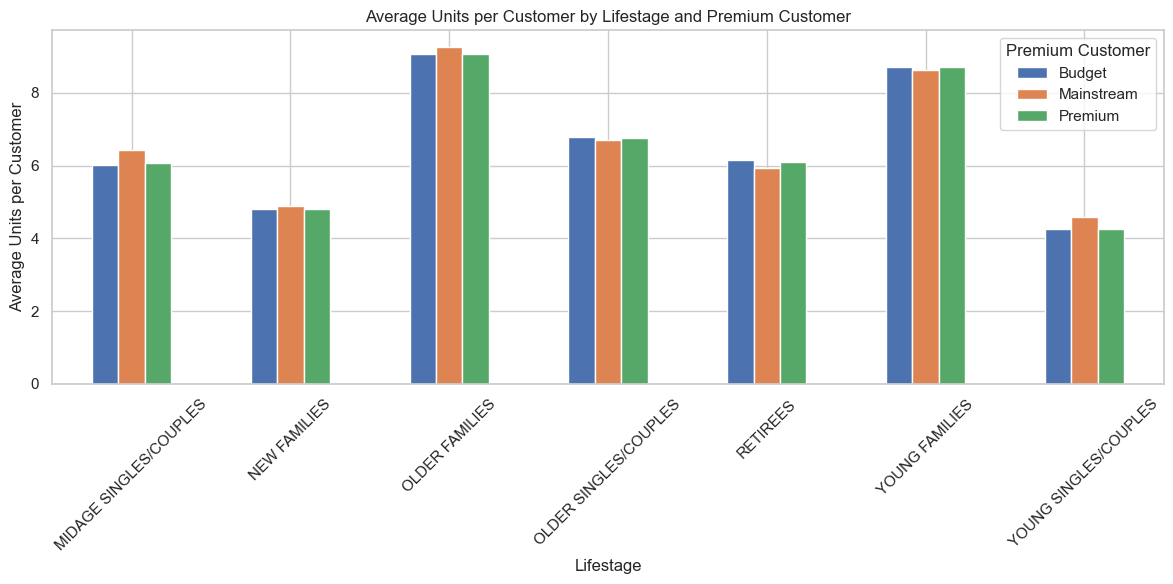

,LIFESTAGE,PREMIUM_CUSTOMER,Avg_Units_Per_Customer
7,OLDER FAMILIES,Mainstream,9.255380
6,OLDER FAMILIES,Budget,9.076773
8,OLDER FAMILIES,Premium,9.071717
15,YOUNG FAMILIES,Budget,8.722995
17,YOUNG FAMILIES,Premium,8.716013
16,YOUNG FAMILIES,Mainstream,8.638361
9,OLDER SINGLES/COUPLES,Budget,6.781398
11,OLDER SINGLES/COUPLES,Premium,6.769543
10,OLDER SINGLES/COUPLES,Mainstream,6.712021
1,MIDAGE SINGLES/COUPLES,Mainstream,6.432080


In [191]:
# Average number of units per customer by LIFESTAGE and PREMIUM_CUSTOMER

# total units (PROD_QTY) per segment
total_units = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"].sum()

# number of unique customers per segment
unique_customers = data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()

# average units per customer
avg_units_per_customer = (total_units / unique_customers).reset_index(name="Avg_Units_Per_Customer")

# pivot for plotting
avg_units_pivot = avg_units_per_customer.pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="Avg_Units_Per_Customer"
).fillna(0)

# plot
avg_units_pivot.plot(kind="bar", figsize=(12,6))

plt.title("Average Units per Customer by Lifestage and Premium Customer")
plt.xlabel("Lifestage")
plt.ylabel("Average Units per Customer")
plt.xticks(rotation=45)
plt.legend(title="Premium Customer")

plt.tight_layout()
plt.show()

# view table
avg_units_per_customer.sort_values("Avg_Units_Per_Customer", ascending=False).head(10)

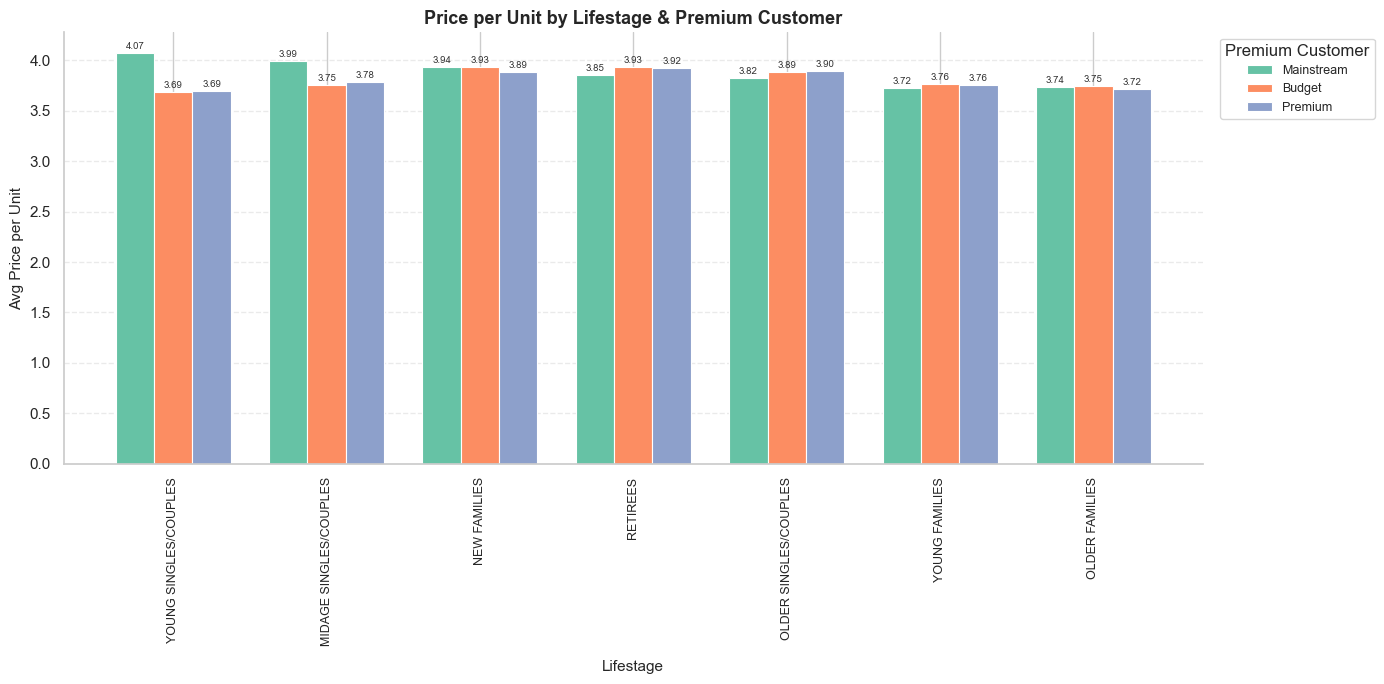

In [246]:
#Older families and young families in general buy more chips per customer
#Let’s also investigate the average price per unit chips bought for each customer segment as this is also a
#driver of total sales.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Calculate average price per unit ──────────────────────────────────────
avg_price = (
    data
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .apply(lambda x: x['TOT_SALES'].sum() / x['PROD_QTY'].sum())
    .reset_index()
    .rename(columns={0: 'AVG'})
    .sort_values('AVG', ascending=False)
)

# ── 2. Set up grouped bar chart variables ─────────────────────────────────────
lifestages = avg_price['LIFESTAGE'].unique()
tiers      = avg_price['PREMIUM_CUSTOMER'].unique()

x          = np.arange(len(lifestages))   # base x positions
n_tiers    = len(tiers)
bar_width  = 0.25                         # width of each individual bar

# ── 3. Colours – one per PREMIUM_CUSTOMER tier ───────────────────────────────
palette = plt.cm.Set2.colors
colours = {tier: palette[i] for i, tier in enumerate(tiers)}

# ── 4. Plot grouped bars ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

for i, tier in enumerate(tiers):
    subset = avg_price[avg_price['PREMIUM_CUSTOMER'] == tier]

    # Align subset to the full lifestage list (fill 0 if missing)
    avg_values = [
        subset.loc[subset['LIFESTAGE'] == ls, 'AVG'].values[0]
        if ls in subset['LIFESTAGE'].values else 0
        for ls in lifestages
    ]

    offset = (i - n_tiers / 2) * bar_width + bar_width / 2

    bars = ax.bar(
        x + offset,
        avg_values,
        width=bar_width,
        label=tier,
        color=colours[tier],
        edgecolor='white',
        linewidth=0.8
    )

    # Value labels on top of each bar
    for bar, val in zip(bars, avg_values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{val:.2f}",
                ha='center', va='bottom',
                fontsize=7, color='#333333'
            )

# ── 5. X-axis labels ──────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(lifestages, rotation=90, va='top', fontsize=9)

# ── 6. Legend ─────────────────────────────────────────────────────────────────
ax.legend(
    title='Premium Customer',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=9
)

# ── 7. Formatting ─────────────────────────────────────────────────────────────
ax.set_title('Price per Unit by Lifestage & Premium Customer',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Lifestage', fontsize=11, labelpad=10)
ax.set_ylabel('Avg Price per Unit', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()



Mainstream midage and young singles and couples are more willing to pay more per packet of chips compared
to their budget and premium counterparts. This may be due to premium shoppers being more likely to
buy healthy snacks and when they buy chips, this is mainly for entertainment purposes rather than their own
consumption. This is also supported by there being fewer premium midage and young singles and couples
buying chips compared to their mainstream counterparts.
As the difference in average price per unit isn’t large, we can check if this difference is statistically different.

In [249]:
#Perform an independent t‐test between mainstream vs premium and budget
# midage and
# young singles and couples

from scipy import stats

# ── 1. Calculate price per unit ───────────────────────────────────────────────
data['price'] = data['TOT_SALES'] / data['PROD_QTY']

# ── 2. Filter to target LIFESTAGE groups ──────────────────────────────────────
target_lifestages = ["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"]

filtered = data[data['LIFESTAGE'].isin(target_lifestages)]

# ── 3. Split into Mainstream vs Non-Mainstream ────────────────────────────────
mainstream = filtered[
    filtered['PREMIUM_CUSTOMER'] == 'Mainstream'
]['price']

non_mainstream = filtered[
    filtered['PREMIUM_CUSTOMER'] != 'Mainstream'
]['price']

# ── 4. One-sided t-test (Mainstream > Non-Mainstream) ────────────────────────
t_stat, p_value = stats.ttest_ind(
    mainstream,
    non_mainstream,
    alternative='greater',    # matches R's alternative = "greater"
    equal_var=False           # Welch's t-test (more robust, R default)
)

# ── 5. Print results ──────────────────────────────────────────────────────────
print("=" * 50)
print("   Welch Two Sample t-test")
print("=" * 50)
print(f"   Mainstream    : n={len(mainstream):,},  mean={mainstream.mean():.4f}")
print(f"   Non-Mainstream: n={len(non_mainstream):,},  mean={non_mainstream.mean():.4f}")
print("-" * 50)
print(f"   t-statistic   : {t_stat:.4f}")
print(f"   p-value       : {p_value:.4f}")
print(f"   Alternative   : Mainstream price > Non-Mainstream price")
print("-" * 50)
print(f"   Result        : {'✅ Significant (p < 0.05)' if p_value < 0.05 else '❌ Not significant (p >= 0.05)'}")
print("=" * 50)

   Welch Two Sample t-test
   Mainstream    : n=30,639,  mean=4.0398
   Non-Mainstream: n=26,728,  mean=3.7065
--------------------------------------------------
   t-statistic   : 37.6244
   p-value       : 0.0000
   Alternative   : Mainstream price > Non-Mainstream price
--------------------------------------------------
   Result        : ✅ Significant (p < 0.05)


In [ ]:
#The t-test results in a p-value < 2.2e-16, i.e. the unit price for mainstream, young and mid-age singles and
#couples are significantly higher than that of budget or premium, young and midage singles and couples.
#Deep dive into specific customer segments for insights
#We have found quite a few interesting insights that we can dive deeper into.
#We might want to target customer segments that contribute the most to sales to retain them or further
#increase sales. Let’s look at Mainstream - young singles/couples. For instance, let’s find out if they tend to
#buy a particular brand of chips.

In [ ]:
#### Deep dive into Mainstream, young singles/couples

In [251]:
import pandas as pd

# ── 1. Split into segment1 and other ─────────────────────────────────────────
segment1 = data[
    (data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
]

other = data[
    ~(
        (data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
        (data['PREMIUM_CUSTOMER'] == 'Mainstream')
    )
]

# ── 2. Total quantity for each group ──────────────────────────────────────────
quantity_segment1 = segment1['PROD_QTY'].sum()
quantity_other    = other['PROD_QTY'].sum()

# ── 3. Brand proportions for segment1 ────────────────────────────────────────
quantity_segment1_by_brand = (
    segment1
    .groupby('BRAND')['PROD_QTY']
    .sum()
    .reset_index()
    .rename(columns={'PROD_QTY': 'targetSegment'})
)
quantity_segment1_by_brand['targetSegment'] = (
    quantity_segment1_by_brand['targetSegment'] / quantity_segment1
)

# ── 4. Brand proportions for other ───────────────────────────────────────────
quantity_other_by_brand = (
    other
    .groupby('BRAND')['PROD_QTY']
    .sum()
    .reset_index()
    .rename(columns={'PROD_QTY': 'other'})
)
quantity_other_by_brand['other'] = (
    quantity_other_by_brand['other'] / quantity_other
)

# ── 5. Merge and calculate affinity score ────────────────────────────────────
brand_proportions = pd.merge(
    quantity_segment1_by_brand,
    quantity_other_by_brand,
    on='BRAND'
)

brand_proportions['affinityToBrand'] = (
    brand_proportions['targetSegment'] / brand_proportions['other']
)

# ── 6. Sort by affinity descending ───────────────────────────────────────────
brand_proportions = brand_proportions.sort_values(
    'affinityToBrand',
    ascending=False
).reset_index(drop=True)

# ── 7. Display results ────────────────────────────────────────────────────────
print("=" * 60)
print("   Brand Affinity — Young Singles/Couples (Mainstream)")
print("=" * 60)
print(f"{'BRAND':<25} {'targetSegment':>14} {'other':>10} {'affinityToBrand':>16}")
print("-" * 60)
for _, row in brand_proportions.iterrows():
    print(
        f"{row['BRAND']:<25} "
        f"{row['targetSegment']:>14.4f} "
        f"{row['other']:>10.4f} "
        f"{row['affinityToBrand']:>16.4f}"
    )
print("=" * 60)

   Brand Affinity — Young Singles/Couples (Mainstream)
BRAND                      targetSegment      other  affinityToBrand
------------------------------------------------------------
TYRRELLS                          0.0316     0.0257           1.2281
TWISTIES                          0.0462     0.0379           1.2193
DORITOS                           0.1228     0.1011           1.2146
KETTLE                            0.1980     0.1656           1.1959
TOSTITOS                          0.0454     0.0380           1.1957
PRINGLES                          0.1194     0.1006           1.1867
GRNWVES                           0.0291     0.0251           1.1593
COBS                              0.0446     0.0390           1.1431
INFUZIONS                         0.0647     0.0571           1.1334
THINS                             0.0604     0.0570           1.0594
CHEEZELS                          0.0180     0.0186           0.9638
SMITHS                            0.0964     0.1246     

In [ ]:
We can see that :
• Mainstream young singles/couples are 23% more likely to purchase Tyrrells chips compared to the
rest of the population
• Mainstream young singles/couples are 56% less likely to purchase Burger Rings compared to the rest
of the population
Let’s also find out if our target segment tends to buy larger packs of chips.
#### Preferred pack size compared to the rest of the population

   Pack Size Affinity — Young Singles/Couples (Mainstream)
PACK_SIZE        targetSegment      other   affinityToPack
-----------------------------------------------------------------
270.0g                  0.0318     0.0251           1.2683
380.0g                  0.0322     0.0256           1.2570
330.0g                  0.0613     0.0502           1.2217
134.0g                  0.1194     0.1006           1.1867
110.0g                  0.1063     0.0898           1.1836
210.0g                  0.0291     0.0251           1.1593
135.0g                  0.0148     0.0131           1.1295
250.0g                  0.0144     0.0128           1.1232
170.0g                  0.0808     0.0810           0.9974
150.0g                  0.1576     0.1634           0.9644
175.0g                  0.2550     0.2700           0.9444
165.0g                  0.0557     0.0623           0.8938
190.0g                  0.0075     0.0124           0.6013
180.0g                  0.0036     0.0061        

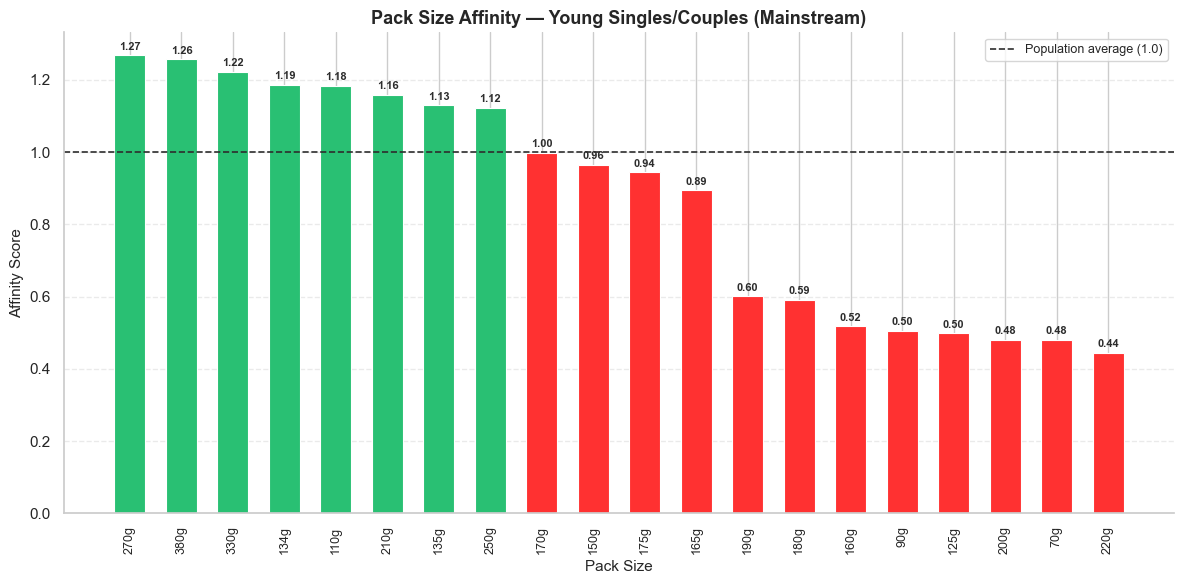

In [253]:
import pandas as pd

# ── 1. Pack size proportions for segment1 ────────────────────────────────────
quantity_segment1_by_pack = (
    segment1
    .groupby('PACK_SIZE')['PROD_QTY']
    .sum()
    .reset_index()
    .rename(columns={'PROD_QTY': 'targetSegment'})
)
quantity_segment1_by_pack['targetSegment'] = (
    quantity_segment1_by_pack['targetSegment'] / quantity_segment1
)

# ── 2. Pack size proportions for other ───────────────────────────────────────
quantity_other_by_pack = (
    other
    .groupby('PACK_SIZE')['PROD_QTY']
    .sum()
    .reset_index()
    .rename(columns={'PROD_QTY': 'other'})
)
quantity_other_by_pack['other'] = (
    quantity_other_by_pack['other'] / quantity_other
)

# ── 3. Merge and calculate affinity score ────────────────────────────────────
pack_proportions = pd.merge(
    quantity_segment1_by_pack,
    quantity_other_by_pack,
    on='PACK_SIZE'
)

pack_proportions['affinityToPack'] = (
    pack_proportions['targetSegment'] / pack_proportions['other']
)

# ── 4. Sort by affinity descending ───────────────────────────────────────────
pack_proportions = pack_proportions.sort_values(
    'affinityToPack',
    ascending=False
).reset_index(drop=True)

# ── 5. Display results ────────────────────────────────────────────────────────
print("=" * 65)
print("   Pack Size Affinity — Young Singles/Couples (Mainstream)")
print("=" * 65)
print(f"{'PACK_SIZE':<15} {'targetSegment':>14} {'other':>10} {'affinityToPack':>16}")
print("-" * 65)
for _, row in pack_proportions.iterrows():
    print(
        f"{str(row['PACK_SIZE'])+'g':<15} "
        f"{row['targetSegment']:>14.4f} "
        f"{row['other']:>10.4f} "
        f"{row['affinityToPack']:>16.4f}"
    )
print("=" * 65)

# ── 6. Optional: bar chart of affinity scores ────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

colours = [
    '#29C073' if val >= 1.0 else '#FF3131'
    for val in pack_proportions['affinityToPack']
]

bars = ax.bar(
    pack_proportions['PACK_SIZE'].astype(str) + 'g',
    pack_proportions['affinityToPack'],
    color=colours,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

# Reference line at 1.0 (population average)
ax.axhline(
    y=1.0,
    color='#2D2D2D',
    linestyle='--',
    linewidth=1.2,
    label='Population average (1.0)'
)

# Value labels on top of each bar
for bar, val in zip(bars, pack_proportions['affinityToPack']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.2f}",
        ha='center', va='bottom',
        fontsize=8, fontweight='bold', color='#2D2D2D'
    )

# ── 7. Formatting ─────────────────────────────────────────────────────────────
ax.set_title(
    'Pack Size Affinity — Young Singles/Couples (Mainstream)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Pack Size', fontsize=11)
ax.set_ylabel('Affinity Score', fontsize=11)
ax.set_xticks(range(len(pack_proportions)))
ax.set_xticklabels(
    pack_proportions['PACK_SIZE'].astype(str) + 'g',
    rotation=90, va='top', fontsize=9
)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
It looks like Mainstream young singles/couples are 27% more likely to purchase a 270g pack of chips compared
to the rest of the population but let’s dive into what brands sell this pack size.

In [255]:
# ── Get unique product names for 270g pack size ───────────────────────────────
unique_products_270 = data[data['PACK_SIZE'] == 270]['PROD_NAME'].unique()

# ── Display results ───────────────────────────────────────────────────────────
print("=" * 55)
print("   Unique Products with Pack Size 270g")
print("=" * 55)
for product in unique_products_270:
    print(f"   • {product}")
print("-" * 55)
print(f"   Total: {len(unique_products_270)} unique product(s)")
print("=" * 55)

   Unique Products with Pack Size 270g
   • Twisties Cheese     270g
   • Twisties Chicken270g
-------------------------------------------------------
   Total: 2 unique product(s)


In [ ]:
Twisties are the only brand offering 270g packs and so this may instead be reflecting a higher likelihood of
purchasing Twisties.
Conclusion
Let’s recap what we’ve found!
Sales have mainly been due to Budget - older families, Mainstream - young singles/couples, and Mainstream
- retirees shoppers. We found that the high spend in chips for mainstream young singles/couples and retirees
is due to there being more of them than other buyers. Mainstream, midage and young singles and
couples are also more likely to pay more per packet of chips. This is indicative of impulse buying behaviour.
We’ve also found that Mainstream young singles and couples are 23% more likely to purchase Tyrrells chips
compared to the rest of the population. The Category Manager may want to increase the category’s performance
by off-locating some Tyrrells and smaller packs of chips in discretionary space near segments
where young singles and couples frequent more often to increase visibilty and impulse behaviour.
Quantium can help the Category Manager with recommendations of where these segments are and further
help them with measuring the impact of the changed placement. We’ll work on measuring the impact of
trials in the next task and putting all these together in the third task.